# Give pUC19 a Golden Gate cloning site

Let's start with an annotated pUC19 plasmid from GenHub and replace its multiple
cloning site (MCS) with a Golden Gate cloning site. You'll work on a local branch
and view the original and edited regions side by side in the notebook.

Run the cells in order with Python 3.11 or newer and the Gen Python package
installed in your notebook kernel. The example downloads a public repository;
your changes stay on your computer.


In [1]:
from pathlib import Path
import tempfile

import gen

work_dir = Path(tempfile.mkdtemp(prefix="gen-golden-gate-"))


## Get your own copy

Clone the public [pUC19 repository](https://www.genhub.bio/repos/bvh/new-api-calls)
into your empty working directory. `gen.clone()` returns an open `Repository`
and accepts a `Path` directly. If you omit `path`, Gen creates a directory named
after the remote repository under your current directory.

The equivalent CLI command is `gen clone https://www.genhub.bio/api/repos/bvh/new-api-calls`.
For private repositories, set `GENHUB_API_KEY` in your environment or reuse
credentials saved by `gen remote login <remote-name>`.


In [2]:
genhub_url = "https://www.genhub.bio/api/repos/bvh/new-api-calls"
repo = gen.clone(genhub_url, path=work_dir)
print("Your local copy:", work_dir)


Your local copy: /var/folders/f8/8zf8xczs0pxf9_vfnlmqlx9h0000gn/T/gen-golden-gate-61qbwukj


## Find the cloning site

Select the pUC19 sample and its sequence graph. Its annotations include an `MCS`
feature, so you can navigate to the cloning site by name without looking up
plasmid coordinates.


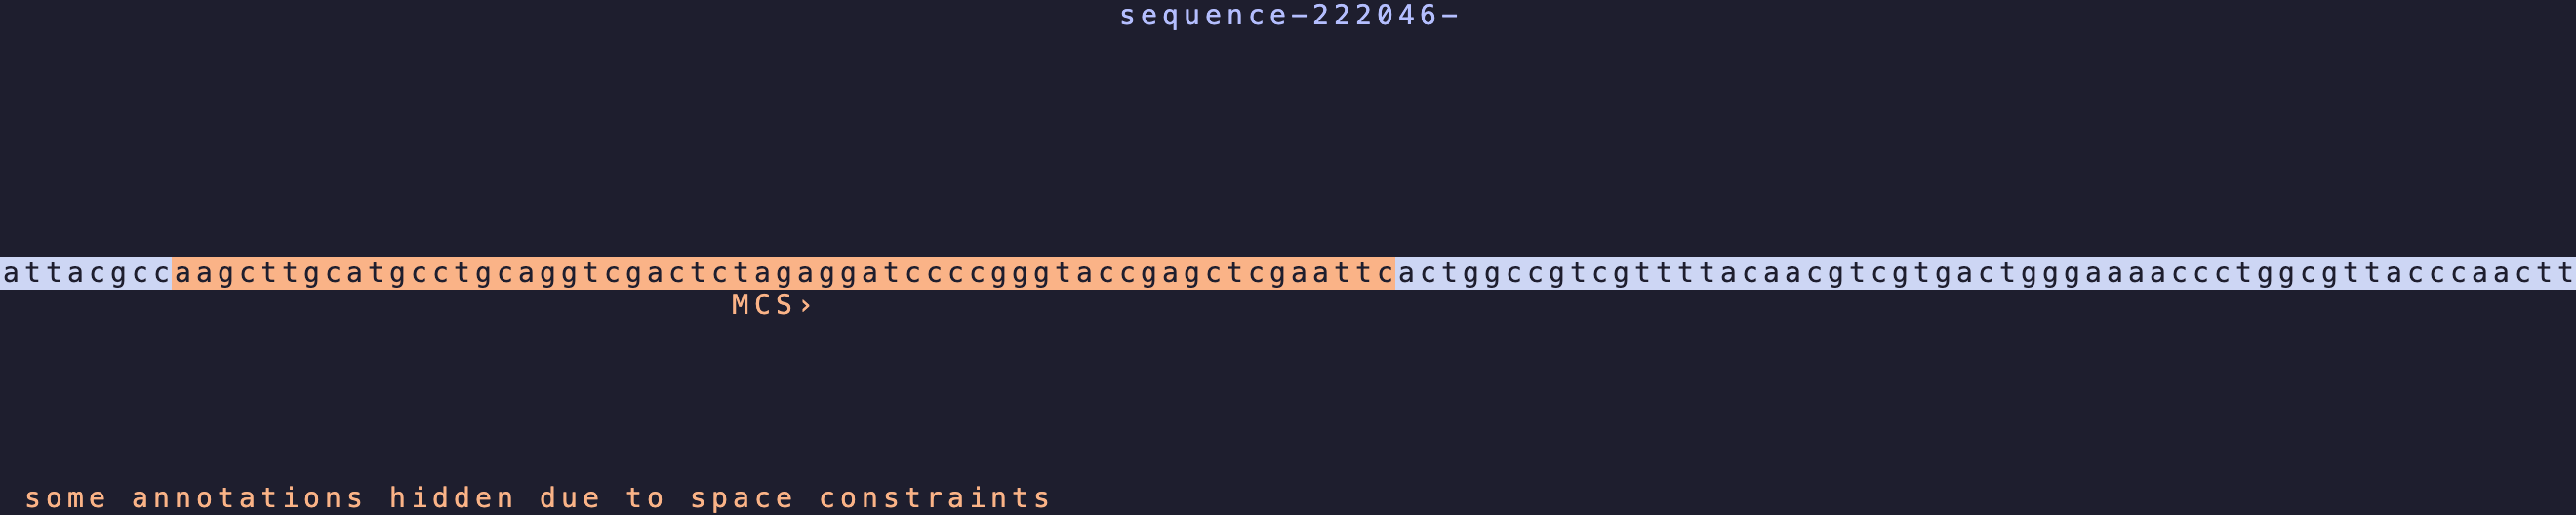

In [3]:
plasmid_sample = next(sample for sample in repo.get_samples() if sample.sample_name == "pUC19")
plasmid = plasmid_sample[0]
mcs = next(annotation for annotation in plasmid.list_annotations() if annotation.name == "MCS")

original_view = plasmid.plot(rows=16, cols=120, detail="full", colors={"MCS": "#f9e2af"})
original_view.show(mcs, center=True)
original_view


## Try a Golden Gate design

Create and switch to a new branch in one call with `checkout(..., create=True)`.
Your `main` branch keeps the original plasmid while you try the new design.


In [4]:
design_branch = repo.checkout("golden-gate", create=True)


Checking out branch golden-gate


Replace the whole MCS with a short example cassette containing two BsaI
recognition sites (`GGTCTC` and its reverse complement, `GAGACC`), used in
[Golden Gate assembly](https://www.neb.com/en-us/products/e1601-nebridge-golden-gate-assembly-mix-basai-hf-v2).

The region `MCS:0-57` spans the 57-base annotation, using zero-based coordinates
with an exclusive end. Derive the end from `len(mcs)` so the code follows the
annotation. `update_with_sequence()` creates the `pUC19_golden_gate` sample and
records the edit on your branch.


In [5]:
golden_gate_mcs = "GAATTCGGTCTCAAATGCATCATCATCATGCATTGAGACCAAGCTT"
edited_sample = repo.update_with_sequence(
    golden_gate_mcs,
    sample=plasmid.sample_name,
    new_sample="pUC19_golden_gate",
    region_name=f"{mcs.name}:0-{len(mcs)}",
    collection=plasmid.collection_name,
)


Updated with sequence.


## See what changed

Open the edited graph and highlight the replacement sequence. Compare it with
the original MCS view above: the new sample has an alternative route through
the Golden Gate cassette.


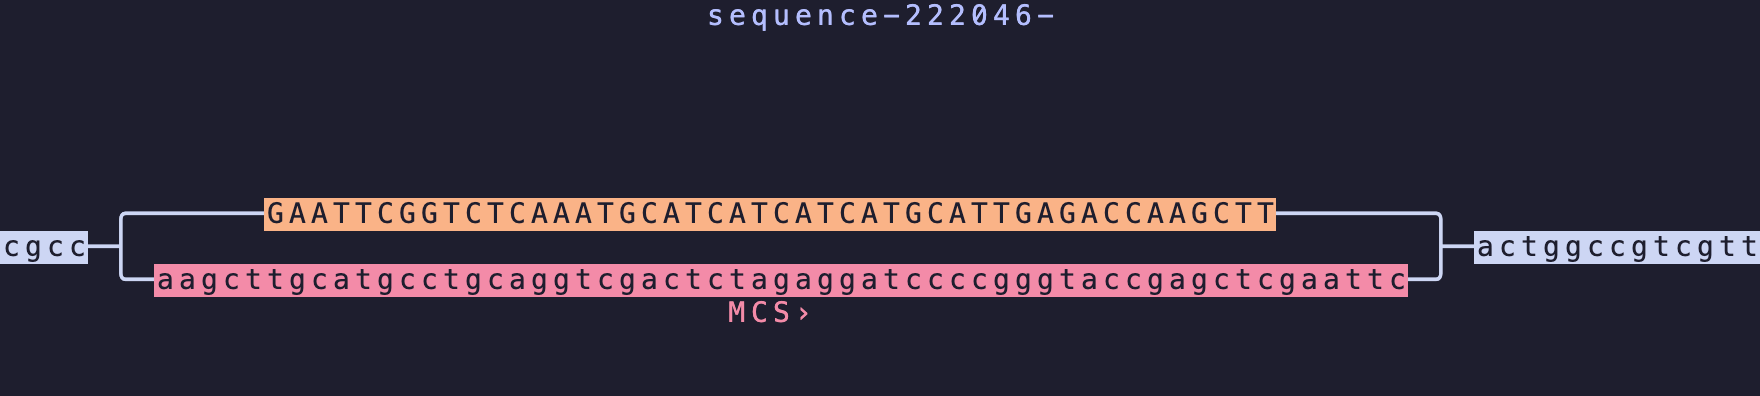

In [14]:
edited_plasmid = edited_sample[0]
replacement = edited_plasmid.search(golden_gate_mcs)[0]
edited_view = edited_plasmid.plot(detail="full", cols=80, colors={"MCS": "#f9e2af"})
edited_view.show(replacement)
edited_view


Switch back to `main` to see the original samples, then return to your design.
`checkout()` accepts either a branch name or the `Branch` object returned when
you created it. Without `create=True`, it switches to an existing branch.


In [7]:
repo.checkout("main")
print("On main:", [sample.sample_name for sample in repo.get_samples()])

repo.checkout(design_branch)
print("On golden-gate:", [sample.sample_name for sample in repo.get_samples()])


On main:Checking out branch main
 ['pUC19']
On golden-gate: ['pUC19', 'pUC19_golden_gate']
Checking out branch golden-gate


Your Golden Gate design is saved on the local `golden-gate` branch. You can
continue editing it or return to `main` whenever you like. Nothing has been
pushed to GenHub.
